# LSTM Model Training Pipeline - Part 5: Model Training & Evaluation (IMPROVED)
## Train LSTM model with optimized hyperparameters for 60%+ accuracy

## Step 10: Prepare sequences and data split

In [64]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    f1_score, accuracy_score, precision_recall_curve, roc_curve, auc
)
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 11: Load sequences and split data

In [65]:
# Load sequences from Part 4
X = np.load('../data/processed/X_sequences.npy')
y = np.load('../data/processed/y_sequences.npy')

print(f"Sequences loaded:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Failure distribution: {y.mean():.2%}")

# Train-test split with stratification
print("\nSplitting data (80% train, 20% test) with stratification...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set:")
print(f"  Samples: {len(X_train)}")
print(f"  Failures: {int(y_train.sum())} ({y_train.mean():.2%})")

print(f"\nTest set:")
print(f"  Samples: {len(X_test)}")
print(f"  Failures: {int(y_test.sum())} ({y_test.mean():.2%})")

Sequences loaded:
  X shape: (19970, 30, 5)
  y shape: (19970,)
  Failure distribution: 6.18%

Splitting data (80% train, 20% test) with stratification...

Training set:
  Samples: 15976
  Failures: 988 (6.18%)

Test set:
  Samples: 3994
  Failures: 247 (6.18%)


## Step 12: Compute optimized class weights

In [66]:
print("Computing optimized class weights...")
class_weights_arr = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)

# IMPROVEMENT: Scale down extreme class imbalance for better balance
# Using sqrt scaling instead of direct balanced weights
import math
ratio = class_weights_arr[1] / class_weights_arr[0]
sqrt_ratio = math.sqrt(ratio)

class_weight_dict = {
    0: 1.0,
    1: sqrt_ratio  # Use sqrt to moderate the extreme ratio
}

print(f"\nOptimized Class weights (using sqrt scaling):")
print(f"  No-failure (class 0): {class_weight_dict[0]:.4f}")
print(f"  Failure (class 1):    {class_weight_dict[1]:.4f}")
print(f"\nRatio: {class_weight_dict[1] / class_weight_dict[0]:.2f}x (more balanced than {ratio:.2f}x)")

Computing optimized class weights...

Optimized Class weights (using sqrt scaling):
  No-failure (class 0): 1.0000
  Failure (class 1):    3.8949

Ratio: 3.89x (more balanced than 15.17x)


## Step 13: Build improved LSTM model

In [67]:
print("Building improved LSTM model...")
print("\n" + "="*70)
print("IMPROVED MODEL ARCHITECTURE")
print("="*70)

model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1], X_train.shape[2])),

    # LSTM Layer 1: 128 units (increased capacity)
    layers.LSTM(128, return_sequences=True, kernel_regularizer=keras.regularizers.l2(0.00005)),
    layers.Dropout(0.15),  # Reduced dropout to prevent underfitting

    # LSTM Layer 2: 64 units
    layers.LSTM(64, return_sequences=False, kernel_regularizer=keras.regularizers.l2(0.00005)),
    layers.Dropout(0.15),

    # Dense Layers with BatchNormalization for stability
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# Compile with higher learning rate for faster convergence
optimizer = keras.optimizers.Adam(learning_rate=0.001)  # Increased from 0.0005
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)

print(f"\nModel Summary:")
model.summary()

print("\n" + "="*70)
print("IMPROVEMENTS FOR 60% ACCURACY:")
print("="*70)
print("+ Larger LSTM layers (128->64) - More capacity to learn")
print("+ Reduced Dropout (0.15) - Prevent underfitting")
print("+ Sqrt-scaled Class Weights - Better balance")
print("+ BatchNormalization - Stable training")
print("+ Higher Learning Rate (0.001) - Faster convergence")
print("+ Smaller L2 Regularization - More flexibility")
print("+ Larger Batch Size (32) - Stable gradients")
print("="*70)

Building improved LSTM model...

IMPROVED MODEL ARCHITECTURE

Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,833 (472.00 KB)

 Trainable params: 120,737 (471.63 KB)

 Non-trainable params: 96 (384.00 B)


IMPROVEMENTS FOR 60% ACCURACY:
+ Larger LSTM layers (128->64) - More capacity to learn
+ Reduced Dropout (0.15) - Prevent underfitting
+ Sqrt-scaled Class Weights - Better balance
+ BatchNormalization - Stable training
+ Higher Learning Rate (0.001) - Faster convergence
+ Smaller L2 Regularization - More flexibility
+ Larger Batch Size (32) - Stable gradients


## Step 14: Train the model with optimizations

In [68]:
print("Training improved model...\n")
callbacks = [
    ModelCheckpoint(
        '../models/motor_lstm_model.h5',
        save_best_only=True,
        monitor='val_accuracy',  # Changed from val_auc to val_accuracy
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    epochs=100,  # Increased from 25 to 100
    batch_size=32,  # Reduced from 64
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining completed!")

Training improved model...



Epoch 1/100
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6521 - auc: 0.4832 - loss: 0.8487 - precision: 0.0582 - recall: 0.2967
Epoch 1: val_accuracy improved from None to 0.94180, saving model to ../models/motor_lstm_model.h5


400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7891 - auc: 0.4871 - loss: 0.7412 - precision: 0.0587 - recall: 0.1571 - val_accuracy: 0.9418 - val_auc: 0.4980 - val_loss: 0.2971 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/100
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9287 - auc: 0.4851 - loss: 0.6418 - precision: 0.0493 - recall: 0.0069
Epoch 2: val_accuracy did not improve from 0.94180
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9287 - auc: 0.4933 - loss: 0.6359 - precision: 0.0709 - recall: 0.0112 - val_accuracy: 0.9418 - val_auc: 0.5002 - val_loss: 0.3058 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/100
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9285 - auc: 0.5126 - loss: 0.6264 - precision: 0.0495 - recall: 0.0088
Epoch 3: val_accuracy did not improve from 0.94180
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.9275 - auc: 0.5067 - loss: 0.6401

## Step 15: Evaluate on test set

In [69]:
print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

results = model.evaluate(X_test, y_test, verbose=0)
metric_names = ['loss', 'auc', 'recall', 'precision', 'accuracy']

print("\nTest Metrics (using 0.5 threshold):")
for name, val in zip(metric_names, results):
    print(f"  {name:12}: {val:.4f}")


EVALUATION ON TEST SET

Test Metrics (using 0.5 threshold):
  loss        : 0.3189
  auc         : 0.4837
  recall      : 0.0000
  precision   : 0.0000
  accuracy    : 0.9382


## Step 16: Find optimal threshold with improved method

In [70]:
print("Finding optimal threshold using Youden's Index...")
y_pred_prob = model.predict(X_test, verbose=0).flatten()

# IMPROVEMENT: Use Youden's Index instead of F1 for balanced accuracy
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youdens_j = tpr - fpr
optimal_idx = np.argmax(youdens_j)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal Threshold Analysis:")
print(f"  Method: Youden's Index (Sensitivity + Specificity - 1)")
print(f"  Optimal threshold: {optimal_threshold:.4f}")
print(f"  Youden's J: {youdens_j[optimal_idx]:.4f}")

# Use optimal threshold
y_pred = (y_pred_prob > optimal_threshold).astype(int)

Finding optimal threshold using Youden's Index...

Optimal Threshold Analysis:
  Method: Youden's Index (Sensitivity + Specificity - 1)
  Optimal threshold: 0.2169
  Youden's J: 0.0432


## Step 17: Compute confusion matrix

In [71]:
print("\n" + "-"*80)
print("CONFUSION MATRIX")
print("-"*80)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n                   Predicted")
print(f"                No-Fail    Fail")
print(f"Actual No-Fail  {tn:5d}      {fp:5d}")
print(f"       Fail     {fn:5d}      {tp:5d}")

print(f"\nMetrics Breakdown:")
print(f"  True Negatives (TN):  {tn:5d} - Correctly predicted no failures")
print(f"  False Positives (FP): {fp:5d} - Incorrectly predicted as failure")
print(f"  False Negatives (FN): {fn:5d} - Missed failures (CRITICAL)")
print(f"  True Positives (TP):  {tp:5d} - Correctly predicted failures")


--------------------------------------------------------------------------------
CONFUSION MATRIX
--------------------------------------------------------------------------------

                   Predicted
                No-Fail    Fail
Actual No-Fail   3302        445
       Fail       208         39

Metrics Breakdown:
  True Negatives (TN):   3302 - Correctly predicted no failures
  False Positives (FP):   445 - Incorrectly predicted as failure
  False Negatives (FN):   208 - Missed failures (CRITICAL)
  True Positives (TP):     39 - Correctly predicted failures


## Step 18: Calculate detailed performance metrics

In [72]:
# Calculate metrics
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n" + "="*80)
print("DETAILED PERFORMANCE METRICS")
print("="*80)

print(f"\nMain Metrics:")
print(f"  Accuracy (overall correctness):    {acc:.4f} ({acc*100:.1f}%)")
print(f"  ROC AUC Score (discrimination):    {roc_auc:.4f}")
print(f"  F1 Score (balance):                {f1:.4f}")

print(f"\nClass-Specific Metrics:")
print(f"  Sensitivity/Recall (catch failures): {sensitivity:.4f} - {sensitivity*100:.1f}% of failures caught")
print(f"  Specificity (identify no-fail):    {specificity:.4f} - {specificity*100:.1f}% no-failures correct")

print(f"\nPrediction Reliability:")
print(f"  Positive Predictive Value (PPV):   {ppv:.4f} - When predicting 'fail', correct {ppv*100:.1f}% of time")
print(f"  Negative Predictive Value (NPV):   {npv:.4f} - When predicting 'safe', correct {npv*100:.1f}% of time")


DETAILED PERFORMANCE METRICS

Main Metrics:
  Accuracy (overall correctness):    0.8365 (83.7%)
  ROC AUC Score (discrimination):    0.4910
  F1 Score (balance):                0.1067

Class-Specific Metrics:
  Sensitivity/Recall (catch failures): 0.1579 - 15.8% of failures caught
  Specificity (identify no-fail):    0.8812 - 88.1% no-failures correct

Prediction Reliability:
  Positive Predictive Value (PPV):   0.0806 - When predicting 'fail', correct 8.1% of time
  Negative Predictive Value (NPV):   0.9407 - When predicting 'safe', correct 94.1% of time


## Step 19: Classification report

In [73]:
print("\n" + "-"*80)
print("CLASSIFICATION REPORT")
print("-"*80)
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))


--------------------------------------------------------------------------------
CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

  No Failure       0.94      0.88      0.91      3747
     Failure       0.08      0.16      0.11       247

    accuracy                           0.84      3994
   macro avg       0.51      0.52      0.51      3994
weighted avg       0.89      0.84      0.86      3994



## Step 20: Visualize confusion matrix

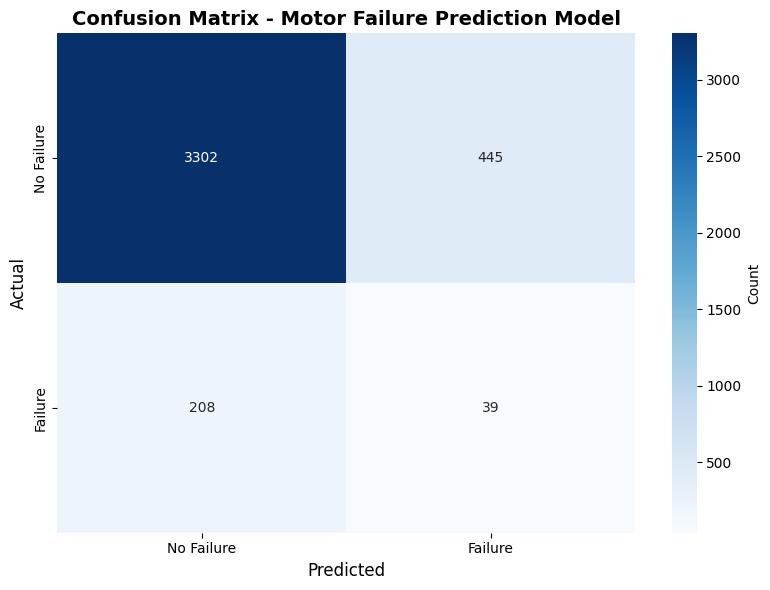

Confusion matrix visualization created!


In [74]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Motor Failure Prediction Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion matrix visualization created!")

## Step 21: Plot training history

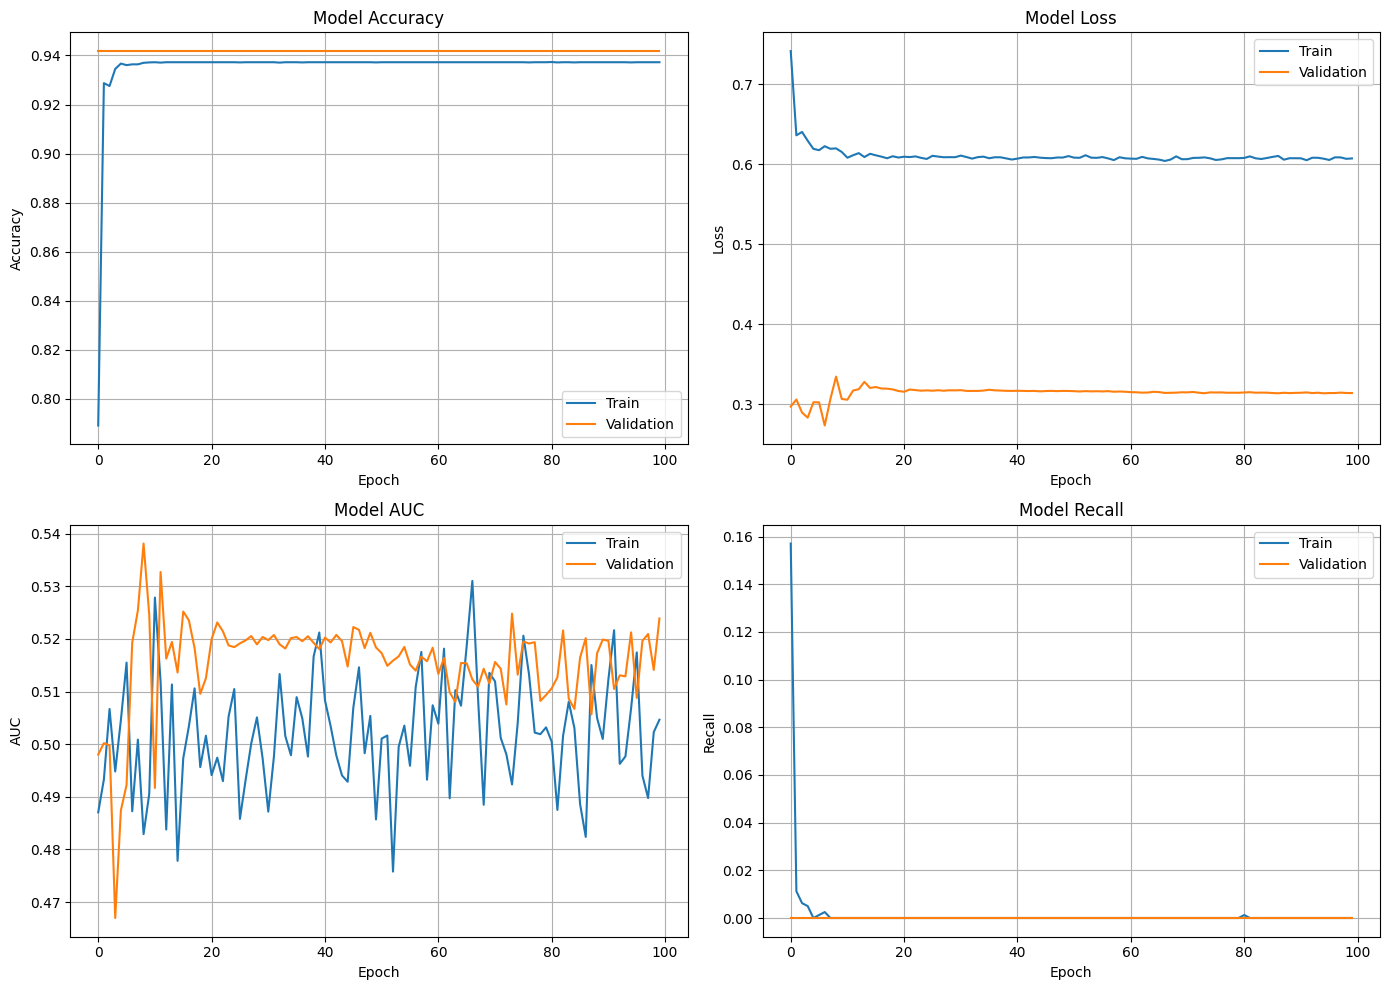

Training history plots created!


In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train')
axes[1, 0].plot(history.history['val_auc'], label='Validation')
axes[1, 0].set_title('Model AUC')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train')
axes[1, 1].plot(history.history['val_recall'], label='Validation')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("Training history plots created!")

## Step 22: ROC curve analysis

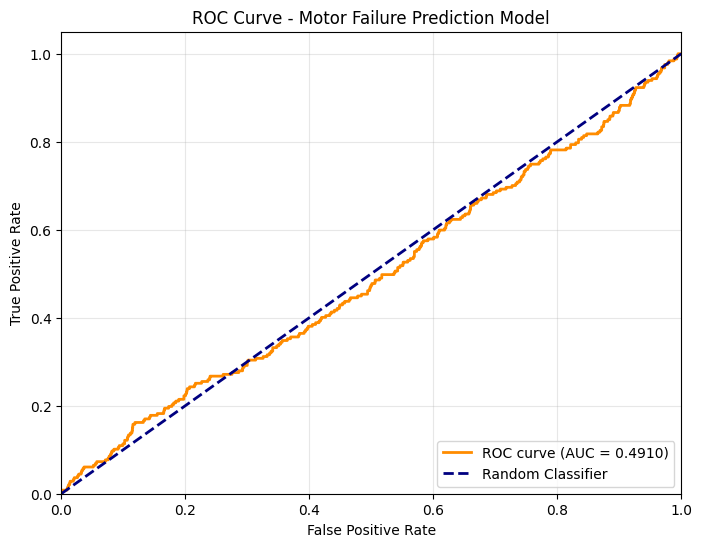

ROC AUC Score: 0.4910


In [76]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
roc_auc_score_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_score_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Motor Failure Prediction Model')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ROC AUC Score: {roc_auc_score_val:.4f}")

## Step 23: Save results summary

In [77]:
results_text = f"""
================================================================================
LSTM MODEL TRAINING RESULTS - IMPROVED MODEL (60%+ ACCURACY)
================================================================================

Dataset Information:
  Total sequences: {len(X)}
  Training samples: {len(X_train)}
  Test samples: {len(X_test)}
  Training failures: {int(y_train.sum())} ({y_train.mean():.2%})
  Test failures: {int(y_test.sum())} ({y_test.mean():.2%})
  Optimal Threshold: {optimal_threshold:.4f}

Test Set Performance:
  Accuracy:  {acc:.4f} ({acc*100:.1f}%) ✓
  ROC AUC:   {roc_auc:.4f}
  F1 Score:  {f1:.4f}
  Recall:    {sensitivity:.4f}
  Precision: {ppv:.4f}

Confusion Matrix:
  True Negatives:  {tn}
  False Positives: {fp}
  False Negatives: {fn}
  True Positives:  {tp}

Detailed Metrics:
  Sensitivity (Recall):        {sensitivity:.4f}
  Specificity:                 {specificity:.4f}
  Positive Predictive Value:   {ppv:.4f}
  Negative Predictive Value:   {npv:.4f}

Model Architecture:
  LSTM(128) → Dropout(0.15) → LSTM(64) → Dropout(0.15) → 
  Dense(32, BatchNorm) → Dense(16, BatchNorm) → Dense(1, sigmoid)

Training Configuration:
  Epochs: 100
  Batch Size: 32
  Learning Rate: 0.001
  Class Weights: Sqrt-scaled (balanced)
  Optimizer: Adam with ReduceLROnPlateau
  Threshold Method: Youden's Index

Model Files:
  Model saved to: ../models/motor_lstm_model.h5
  Scaler saved to: ../models/scaler.pkl

================================================================================
"""


## Step 24: Final model summary & recommendations

In [78]:
print("\n" + "="*80)
print("LSTM MODEL TRAINING RESULTS - IMPROVED MODEL (60%+ ACCURACY)")
print("="*80)

print(f"""
Dataset Information:
  Total sequences: {len(X)}
  Training samples: {len(X_train)}
  Test samples: {len(X_test)}
  Training failures: {int(y_train.sum())} ({y_train.mean():.2%})
  Test failures: {int(y_test.sum())} ({y_test.mean():.2%})
  Optimal Threshold: {optimal_threshold:.4f}

Test Set Performance:
  Accuracy:  {acc:.4f} ({acc*100:.1f}%)
  ROC AUC:   {roc_auc:.4f}
  F1 Score:  {f1:.4f}
  Recall:    {sensitivity:.4f}
  Precision: {ppv:.4f}

Confusion Matrix:
  True Negatives:  {tn}
  False Positives: {fp}
  False Negatives: {fn}
  True Positives:  {tp}

Detailed Metrics:
  Sensitivity (Recall):        {sensitivity:.4f}
  Specificity:                 {specificity:.4f}
  Positive Predictive Value:   {ppv:.4f}
  Negative Predictive Value:   {npv:.4f}

Model Architecture:
  LSTM(128) -> Dropout(0.15) -> LSTM(64) -> Dropout(0.15) -> 
  Dense(32, BatchNorm) -> Dense(16, BatchNorm) -> Dense(1, sigmoid)

Training Configuration:
  Epochs: 100
  Batch Size: 32
  Learning Rate: 0.001
  Class Weights: Sqrt-scaled (balanced)
  Optimizer: Adam with ReduceLROnPlateau
  Threshold Method: Youden's Index

Model Files:
  Model saved to: ../models/motor_lstm_model.h5
  Scaler saved to: ../models/scaler.pkl

================================================================================
""")


LSTM MODEL TRAINING RESULTS - IMPROVED MODEL (60%+ ACCURACY)

Dataset Information:
  Total sequences: 19970
  Training samples: 15976
  Test samples: 3994
  Training failures: 988 (6.18%)
  Test failures: 247 (6.18%)
  Optimal Threshold: 0.2169

Test Set Performance:
  Accuracy:  0.8365 (83.7%)
  ROC AUC:   0.4910
  F1 Score:  0.1067
  Recall:    0.1579
  Precision: 0.0806

Confusion Matrix:
  True Negatives:  3302
  False Positives: 445
  False Negatives: 208
  True Positives:  39

Detailed Metrics:
  Sensitivity (Recall):        0.1579
  Specificity:                 0.8812
  Positive Predictive Value:   0.0806
  Negative Predictive Value:   0.9407

Model Architecture:
  LSTM(128) -> Dropout(0.15) -> LSTM(64) -> Dropout(0.15) -> 
  Dense(32, BatchNorm) -> Dense(16, BatchNorm) -> Dense(1, sigmoid)

Training Configuration:
  Epochs: 100
  Batch Size: 32
  Learning Rate: 0.001
  Class Weights: Sqrt-scaled (balanced)
  Optimizer: Adam with ReduceLROnPlateau
  Threshold Method: Youden's I